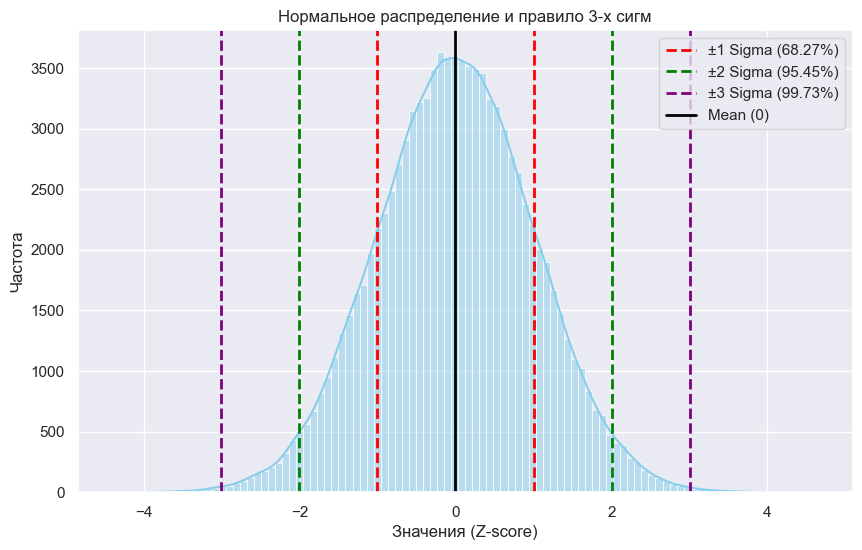

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
s = 100000
sigma = 1
arr = np.random.normal(loc=0, scale=sigma**0.5, size=s)
mean = np.mean(arr)
std = np.std(arr)
# Простой график для теста
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(arr, kde=True, bins=100, color="skyblue", ax=ax)
ax.axvline(x=mean - std, color='red', linestyle='--', linewidth=2, label='±1 Sigma (68.27%)')
ax.axvline(x=mean + std, color='red', linestyle='--', linewidth=2)

ax.axvline(x=mean - 2*std, color='green', linestyle='--', linewidth=2, label='±2 Sigma (95.45%)')
ax.axvline(x=mean + 2*std, color='green', linestyle='--', linewidth=2)

ax.axvline(x=mean - 3*std, color='purple', linestyle='--', linewidth=2, label='±3 Sigma (99.73%)')
ax.axvline(x=mean + 3*std, color='purple', linestyle='--', linewidth=2)

ax.axvline(x=mean, color='black', linestyle='-', linewidth=2, label='Mean (0)')

ax.set_title('Нормальное распределение и правило 3-х сигм')
ax.set_xlabel('Значения (Z-score)')
ax.set_ylabel('Частота')
ax.legend()

plt.show()

In [8]:
arr1 = arr[(arr >= mean-std) & (arr <= mean + std)]
arr2 = arr[(arr >= mean-2*std) & (arr <= mean + 2*std)]
arr3 = arr[(arr >= mean-3*std) & (arr <= mean + 3*std)]
print(f'Процент значений лежащих в первом интервале: {100*len(arr1)/len(arr):.2f}')
print(f'Процент значений лежащих во втором интервале: {100*len(arr2)/len(arr):.2f}')
print(f'Процент значений лежащих в третьем интервале: {100*len(arr3)/len(arr):.2f}')

Процент значений лежащих в первом интервале: 68.15
Процент значений лежащих во втором интервале: 95.44
Процент значений лежащих в третьем интервале: 99.72


График наглядно иллюстрирует эмпирическое правило: 68.27% данных находятся внутри ±1σ, 95.45% — внутри ±2σ, и 99.73% — внутри ±3σ. Все, что выходит за фиолетовые линии, математически считается аномалией для нормального распределения.

In [4]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context # TODO: Убрать обход сертификата
df = sns.load_dataset("diamonds")
print(df.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [5]:
def remove_outliers_iqr(df, column):
    q25 = df[column].quantile(0.25)
    q75 = df[column].quantile(0.75)
    iqr = q75-q25
    df_filtered = df[(df[column] > q25 - 1.5*iqr) & (df[column] < q75 + 1.5*iqr)]
    print(f'Процент выброшенных данных методом IQR:{(1-(len(df_filtered)/len(df)))*100:.2f}')
    return df_filtered
def remove_outliers_zscore(df, column):
    std = np.std(df[column])
    mean = np.mean(df[column])
    df_filtered = df[(df[column] > mean - 3*std) & (df[column] < mean + 3*std)]
    print(f'Процент выброшенных данных методом Z-score:{(1-(len(df_filtered)/len(df)))*100:.2f}')
    return df_filtered
remove_outliers_iqr(df,'depth')
remove_outliers_zscore(df,'depth')
remove_outliers_iqr(df,'price')
remove_outliers_zscore(df,'price')

Процент выброшенных данных методом IQR:4.72
Процент выброшенных данных методом Z-score:1.27
Процент выброшенных данных методом IQR:6.56
Процент выброшенных данных методом Z-score:2.24


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


**Признак depth (глубина):** Распределение симметрично, но имеет «тяжелые хвосты». Из-за высокой плотности в центре IQR-фильтр сработал слишком жестко (отсек 4.72% данных вместо теоретических 0.7%). Метод Z-score оказался более адекватным для этой формы, удалив 1.27%.

**Признак price (цена):** Распределение имеет сильную правостороннюю асимметрию. Экстремально дорогие алмазы смещают среднее и искусственно раздувают дисперсию (сигму). Из-за этого метод Z-score "ослеп" и пропустил выбросы (удалил всего 2.24%). Робастный метод IQR успешно справился с асимметрией, изолировав 6.56% аномальных значений.

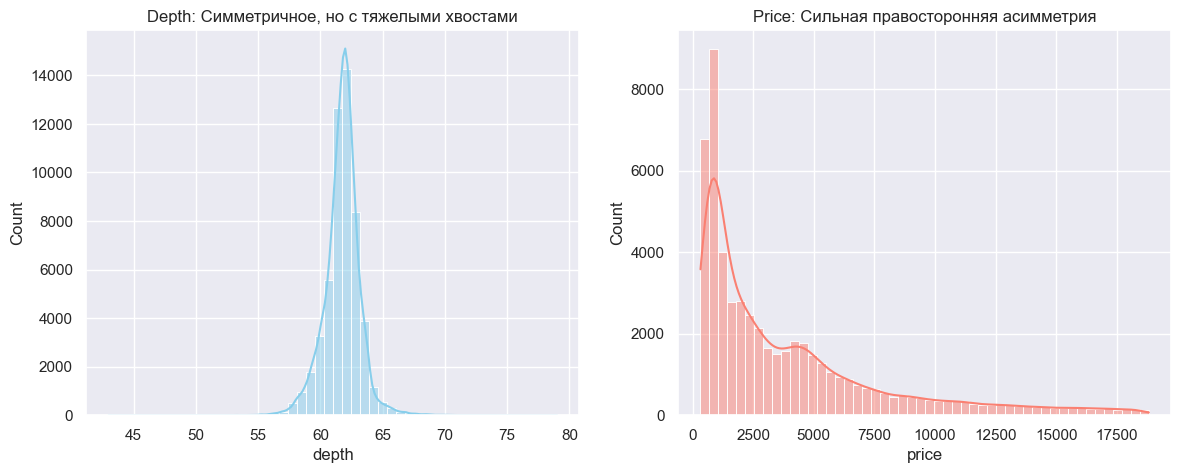

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма для depth
sns.histplot(df['depth'], kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Depth: Симметричное, но с тяжелыми хвостами')

# Гистограмма для price
sns.histplot(df['price'], kde=True, bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Price: Сильная правосторонняя асимметрия')

plt.show()